# Preparation

In [2]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt


In [3]:
# Part-worth utilities from conjoint survey
# alpha calibrated so current £9.99 reflects ~25% conversion (industry benchmark)

betas = {
    'symptom_management': 0.21,
    'fertility_partner':  0.19,
    'health_content':     0.10,
    'ai_assistance':      0.06,
    'price':             -0.30
}

features = ['symptom_management', 'fertility_partner',
            'health_content', 'ai_assistance']

labels = {
    'symptom_management': 'Symptom Management',
    'fertility_partner':  'Fertility & Partner',
    'health_content':     'Health Content',
    'ai_assistance':      'AI Assistance',
}

# WTP = -beta_feature / alpha
wtp = {k: round(-betas[k] / betas['price'], 2) for k in features}

print("WTP per Feature (£/month)")
print("-" * 35)
for k in features:
    print(f"  {labels[k]:<25}  £{wtp[k]:.2f}")


WTP per Feature (£/month)
-----------------------------------
  Symptom Management         £0.70
  Fertility & Partner        £0.63
  Health Content             £0.33
  AI Assistance              £0.20


In [4]:
# MNL: P(j) = exp(V_j) / sum_k exp(V_k)
# Based on Random Utility Model with Gumbel-distributed errors (McFadden 1974)

def compute_utility(feature_keys, price, betas):
    return sum(betas[f] for f in feature_keys) + betas['price'] * price

def mnl_shares(utilities):
    u = np.array(utilities, dtype=float)
    u -= u.max()    # numerical stability
    exp_u = np.exp(u)
    return exp_u / exp_u.sum()

def premium_strategy(price):
    """2-tier: Free vs Premium at given price."""
    V_free = compute_utility([], 0, betas)
    V_prem = compute_utility(features, price, betas)
    s = mnl_shares([V_free, V_prem])
    return s, s[1] * price


In [5]:
shares_cur, rev_cur = premium_strategy(9.99)

print(f"{'Baseline: Current Pricing (£9.99)':=<45}")
print(f"  Free:             {shares_cur[0]*100:.1f}%")
print(f"  Premium:          {shares_cur[1]*100:.1f}%")
print(f"  Revenue per user: £{rev_cur:.3f}")


Baseline: Current Pricing (£9.99)============
  Free:             92.0%
  Premium:          8.0%
  Revenue per user: £0.803


In [6]:
# max_{p} p * s_premium(p)
# ML predicts shares given price, but cannot solve this optimisation —
# that requires the economic structure (MNL + RUM).

def neg_revenue(p):
    _, rev = premium_strategy(p[0])
    return -rev

res = minimize(neg_revenue, 
               x0=[9.99], 
               bounds=[(2.0, 20.0)], 
               method='L-BFGS-B')
opt_price = round(res.x[0], 2)

shares_opt, rev_opt = premium_strategy(opt_price)
uplift = (rev_opt - rev_cur) / rev_cur * 100

print(f"{'Optimised 2-Tier Pricing':=<45}")
print(f"  Optimal Premium price:  £{opt_price}")
print(f"  Free:             {shares_opt[0]*100:.1f}%")
print(f"  Premium:          {shares_opt[1]*100:.1f}%")
print(f"  Revenue per user: £{rev_opt:.3f}  (+{uplift:.1f}% vs current)")


Optimised 2-Tier Pricing=====================
  Optimal Premium price:  £4.74
  Free:             70.3%
  Premium:          29.7%
  Revenue per user: £1.407  (+75.2% vs current)


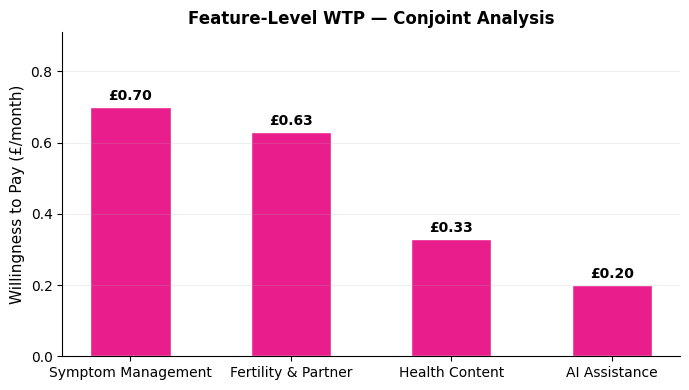

In [7]:
PINK = '#e91e8c'
TEAL = '#00c9a7'
GRAY = '#aaaaaa'

fig, ax = plt.subplots(figsize=(7, 4))

feat_labels = [labels[k] for k in features]
wtp_vals    = [wtp[k] for k in features]

bars = ax.bar(feat_labels, wtp_vals, color=PINK, width=0.5, edgecolor='white')
for b, v in zip(bars, wtp_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f'£{v:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Willingness to Pay (£/month)', fontsize=11)
ax.set_title('Feature-Level WTP — Conjoint Analysis', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(wtp_vals) * 1.3)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


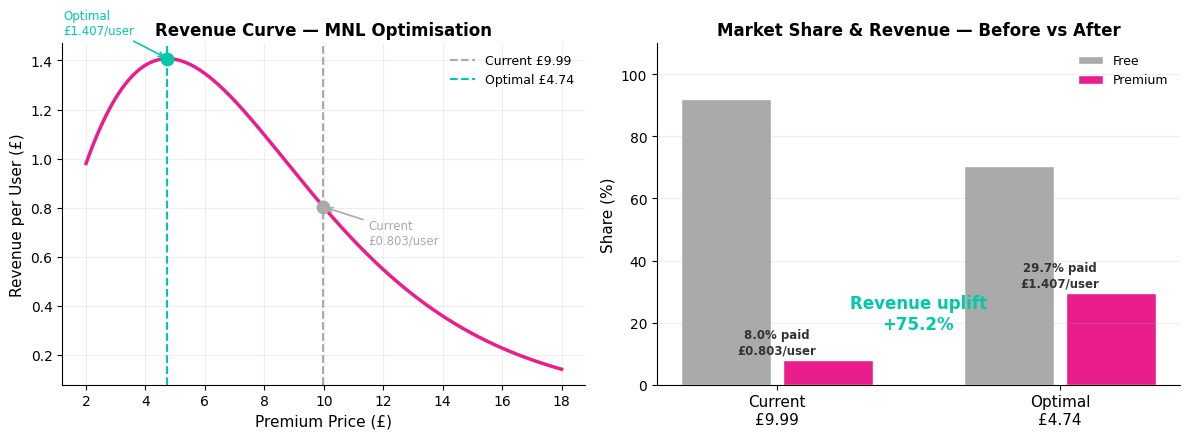

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: Revenue Curve ────────────────────────────────────────────────────
ax = axes[0]
price_range = np.linspace(2, 18, 300)
rev_curve   = [premium_strategy(p)[1] for p in price_range]

ax.plot(price_range, rev_curve, color=PINK, lw=2.5)
ax.axvline(9.99,      color=GRAY, linestyle='--', lw=1.5, label='Current £9.99')
ax.axvline(opt_price, color=TEAL, linestyle='--', lw=1.5, label=f'Optimal £{opt_price}')
ax.scatter([9.99],      [rev_cur],  color=GRAY, s=80, zorder=5)
ax.scatter([opt_price], [rev_opt],  color=TEAL, s=80, zorder=5)

ax.annotate(f'Current\n£{rev_cur:.3f}/user',
            xy=(9.99, rev_cur), xytext=(11.5, rev_cur - 0.15),
            fontsize=8.5, color=GRAY,
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.2))
ax.annotate(f'Optimal\n£{rev_opt:.3f}/user',
            xy=(opt_price, rev_opt), xytext=(opt_price - 3.5, rev_opt + 0.1),
            fontsize=8.5, color=TEAL,
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.2))

ax.set_xlabel('Premium Price (£)', fontsize=11)
ax.set_ylabel('Revenue per User (£)', fontsize=11)
ax.set_title('Revenue Curve — MNL Optimisation', fontweight='bold', fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.grid(alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── Right: Before vs After ─────────────────────────────────────────────────
ax = axes[1]
scenario_labels = [f'Current\n£9.99', f'Optimal\n£{opt_price}']
free_s = [shares_cur[0]*100, shares_opt[0]*100]
prem_s = [shares_cur[1]*100, shares_opt[1]*100]
revs   = [rev_cur, rev_opt]

x = np.arange(2)
ax.bar(x - 0.18, free_s, 0.32, color=GRAY, label='Free',    edgecolor='white')
ax.bar(x + 0.18, prem_s, 0.32, color=PINK, label='Premium', edgecolor='white')

for i, (ps, rv) in enumerate(zip(prem_s, revs)):
    ax.text(i, ps + 2, f'{ps:.1f}% paid\n£{rv:.3f}/user',
            ha='center', fontsize=8.5, fontweight='bold', color='#333')

uplift = (rev_opt - rev_cur) / rev_cur * 100
ax.text(0.5, max(prem_s) * 0.6,
        f'Revenue uplift\n+{uplift:.1f}%',
        ha='center', fontsize=12, fontweight='bold', color=TEAL)

ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, fontsize=11)
ax.set_ylabel('Share (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Market Share & Revenue — Before vs After', fontweight='bold', fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [9]:
# ── Variable Cost Structure ────────────────────────────────────────────────
# Premium features are personalised → each paying user incurs a marginal cost.
# These are NOT fixed costs — they scale directly with the number of paid users.

feature_costs = {
    'symptom_management': 0.40,   # ML inference + symptom pattern analysis
    'fertility_partner':  0.35,   # Personalised cycle modelling + partner sync
    'health_content':     0.15,   # Content delivery + library updates
    'ai_assistance':      0.60,   # LLM API calls per user (highest cost)
}

cost_premium = sum(feature_costs[f] for f in features)

print("Per-Feature Variable Cost (£/user/month)")
print("─" * 42)
for f in features:
    print(f"  {labels[f]:<25}  £{feature_costs[f]:.2f}")
print("─" * 42)
print(f"  {'Total Premium cost':<25}  £{cost_premium:.2f}")
print()
print(f"  Break-even price (min):   £{cost_premium:.2f}")
print(f"  Current price:            £9.99")
print(f"  Gross margin at £9.99:    £{9.99 - cost_premium:.2f}/user  "
      f"({(9.99 - cost_premium) / 9.99 * 100:.0f}%)")

# ── Profit-maximising price with variable cost ─────────────────────────────
def neg_profit_var(p):
    s, _ = premium_strategy(p[0])
    return -(p[0] - cost_premium) * s[1]

res_pv       = minimize(neg_profit_var, x0=[9.99],
                        bounds=[(cost_premium + 0.01, 20.0)],
                        method='L-BFGS-B')

opt_prof_var = round(res_pv.x[0], 2)
shares_pv, _ = premium_strategy(opt_prof_var)
profit_pv    = (opt_prof_var - cost_premium) * shares_pv[1]

profit_cur_var = (9.99      - cost_premium) * shares_cur[1]
profit_opt_var = (opt_price - cost_premium) * shares_opt[1]

print()
print(f"{'Strategy':<28} {'Price':>6}  {'Conv':>7}  {'Profit/user':>12}")
print('─' * 60)
print(f"{'Current':<28} {'£9.99':>6}  "
      f"{shares_cur[1]*100:>6.1f}%  £{profit_cur_var:>10.3f}")
print(f"{'Revenue-maximising':<28} £{opt_price:>5.2f}  "
      f"{shares_opt[1]*100:>6.1f}%  £{profit_opt_var:>10.3f}")
print(f"{'Profit-maximising (var c)':<28} £{opt_prof_var:>5.2f}  "
      f"{shares_pv[1]*100:>6.1f}%  £{profit_pv:>10.3f}")


Per-Feature Variable Cost (£/user/month)
──────────────────────────────────────────
  Symptom Management         £0.40
  Fertility & Partner        £0.35
  Health Content             £0.15
  AI Assistance              £0.60
──────────────────────────────────────────
  Total Premium cost         £1.50

  Break-even price (min):   £1.50
  Current price:            £9.99
  Gross margin at £9.99:    £8.49/user  (85%)

Strategy                      Price     Conv   Profit/user
────────────────────────────────────────────────────────────
Current                       £9.99     8.0%  £     0.683
Revenue-maximising           £ 4.74    29.7%  £     0.962
Profit-maximising (var c)    £ 5.84    23.3%  £     1.011


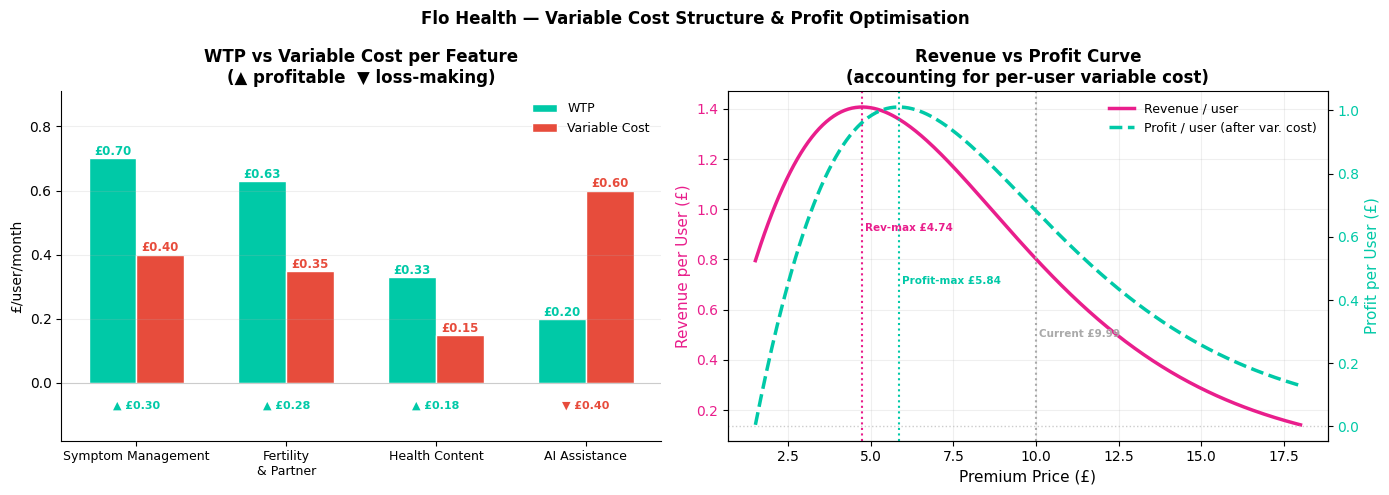

In [10]:
PINK = '#e91e8c'
TEAL = '#00c9a7'
GRAY = '#aaaaaa'
RED  = '#e74c3c'

price_range  = np.linspace(cost_premium + 0.01, 18, 300)
profit_curve = [(p - cost_premium) * premium_strategy(p)[0][1] for p in price_range]
rev_curve    = [premium_strategy(p)[1] for p in price_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: WTP vs Cost grouped bar ─────────────────────────────────────────
ax = axes[0]
feat_labels_s = [labels[f].replace(' & ', '\n& ') for f in features]
cost_vals     = [feature_costs[f] for f in features]
wtp_vals_l    = [wtp[f] for f in features]

x = np.arange(len(features))
w = 0.32
bars_wtp  = ax.bar(x - w/2, wtp_vals_l, w, color=TEAL, label='WTP',           edgecolor='white')
bars_cost = ax.bar(x + w/2, cost_vals,  w, color=RED,  label='Variable Cost',  edgecolor='white')

for i, (wv, cv) in enumerate(zip(wtp_vals_l, cost_vals)):
    ax.text(i - w/2, wv + 0.01, f'£{wv:.2f}', ha='center', fontsize=8.5, fontweight='bold', color=TEAL)
    ax.text(i + w/2, cv + 0.01, f'£{cv:.2f}', ha='center', fontsize=8.5, fontweight='bold', color=RED)
    # Profit/loss label below x-axis
    margin = wv - cv
    col    = TEAL if margin >= 0 else RED
    ax.text(i, -0.08, f'{"▲" if margin>=0 else "▼"} £{abs(margin):.2f}',
            ha='center', fontsize=8, color=col, fontweight='bold')

ax.axhline(0, color='#ccc', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feat_labels_s, fontsize=9)
ax.set_ylabel('£/user/month')
ax.set_ylim(-0.18, max(max(wtp_vals_l), max(cost_vals)) * 1.3)
ax.set_title('WTP vs Variable Cost per Feature\n(▲ profitable  ▼ loss-making)',
             fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── Right: Revenue vs Profit curve ─────────────────────────────────────────
ax  = axes[1]
ax2 = ax.twinx()

l1, = ax.plot(price_range, rev_curve,    color=PINK, lw=2.5, label='Revenue / user')
l2, = ax2.plot(price_range, profit_curve, color=TEAL, lw=2.5,
               linestyle='--', label='Profit / user (after var. cost)')

ax2.axhline(0, color='#ccc', lw=1, linestyle=':')
# 删掉这两行（break-even线和标注）：
# ax.axvline(cost_premium, color=RED,  lw=1.5, linestyle=':')
# ax.text(cost_premium + 0.1, max(rev_curve) * 0.95,
#         f'Break-even\n£{cost_premium:.2f}', fontsize=8, color=RED)

# 替换三根竖线的标注部分：
for price, col, tag, height in [
    (9.99,         GRAY, f'Current £9.99',      0.35),
    (opt_price,    PINK, f'Rev-max £{opt_price}', 0.65),
    (opt_prof_var, TEAL, f'Profit-max £{opt_prof_var}', 0.50),
]:
    ax.axvline(price, color=col, linestyle=':', lw=1.5)
    ax.text(price + 0.1, max(rev_curve) * height, tag,
            fontsize=7.5, color=col, fontweight='bold')

ax.set_xlabel('Premium Price (£)', fontsize=11)
ax.set_ylabel('Revenue per User (£)', color=PINK, fontsize=11)
ax2.set_ylabel('Profit per User (£)',  color=TEAL, fontsize=11)
ax.tick_params(axis='y', labelcolor=PINK)
ax2.tick_params(axis='y', labelcolor=TEAL)
ax.set_title('Revenue vs Profit Curve\n(accounting for per-user variable cost)',
             fontweight='bold')
ax.legend(handles=[l1, l2], fontsize=9, frameon=False)
ax.grid(alpha=0.2)
ax.spines[['top']].set_visible(False)

fig.suptitle('Flo Health — Variable Cost Structure & Profit Optimisation',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
# ── Decision: Remove AI Assistance from Premium ────────────────────────────
# WTP (£0.20) < Variable Cost (£0.60) → including AI destroys value.
# Revised Premium = Symptom Management + Fertility & Partner + Health Content

features_new  = ['symptom_management', 'fertility_partner', 'health_content']
cost_new      = sum(feature_costs[f] for f in features_new)

def premium_strategy_new(price):
    V_free = compute_utility([],           0,     betas)
    V_prem = compute_utility(features_new, price, betas)
    s = mnl_shares([V_free, V_prem])
    return s, s[1] * price

# Re-optimise: revenue-max
def neg_rev_new(p):
    _, rev = premium_strategy_new(p[0])
    return -rev

res_new      = minimize(neg_rev_new, x0=[opt_price],
                        bounds=[(2.0, 20.0)], method='L-BFGS-B')
opt_price_new = round(res_new.x[0], 2)
shares_new, rev_new = premium_strategy_new(opt_price_new)

# Re-optimise: profit-max (without AI cost)
def neg_profit_new(p):
    s, _ = premium_strategy_new(p[0])
    return -(p[0] - cost_new) * s[1]

res_pv_new       = minimize(neg_profit_new, x0=[opt_price_new],
                             bounds=[(cost_new + 0.01, 20.0)], method='L-BFGS-B')
opt_prof_new     = round(res_pv_new.x[0], 2)
shares_pv_new, _ = premium_strategy_new(opt_prof_new)
profit_new       = (opt_prof_new - cost_new) * shares_pv_new[1]

# Compare: old Premium (4 features) vs new Premium (3 features)
profit_old = (opt_prof_var - cost_premium) * shares_pv[1]

print("Decision: Remove AI Assistance (WTP < Cost)")
print("═" * 55)
print(f"  Old Premium (4 features)  cost/user: £{cost_premium:.2f}")
print(f"  New Premium (3 features)  cost/user: £{cost_new:.2f}  (−£{cost_premium-cost_new:.2f})")
print()
print(f"{'Metric':<30} {'Old (4 feat)':>13} {'New (3 feat)':>13}")
print("─" * 58)
print(f"{'Revenue-max price':<30} £{opt_price:>11.2f} £{opt_price_new:>11.2f}")
print(f"{'Conversion at rev-max':<30} {shares_opt[1]*100:>12.1f}% {shares_new[1]*100:>12.1f}%")
print(f"{'Revenue/user at rev-max':<30} £{rev_opt:>11.3f} £{rev_new:>11.3f}")
print(f"{'Profit-max price':<30} £{opt_prof_var:>11.2f} £{opt_prof_new:>11.2f}")
print(f"{'Profit/user at profit-max':<30} £{profit_old:>11.3f} £{profit_new:>11.3f}")
print()
uplift = (profit_new - profit_old) / profit_old * 100
print(f"  Profit uplift from removing AI: +{uplift:.1f}%")


Decision: Remove AI Assistance (WTP < Cost)
═══════════════════════════════════════════════════════
  Old Premium (4 features)  cost/user: £1.50
  New Premium (3 features)  cost/user: £0.90  (−£0.60)

Metric                          Old (4 feat)  New (3 feat)
──────────────────────────────────────────────────────────
Revenue-max price              £       4.74 £       4.68
Conversion at rev-max                  29.7%         28.8%
Revenue/user at rev-max        £      1.407 £      1.349
Profit-max price               £       5.84 £       5.34
Profit/user at profit-max      £      1.011 £      1.107

  Profit uplift from removing AI: +9.5%


C:\Users\步步高点读机\AppData\Local\Temp\ipykernel_41548\895896977.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


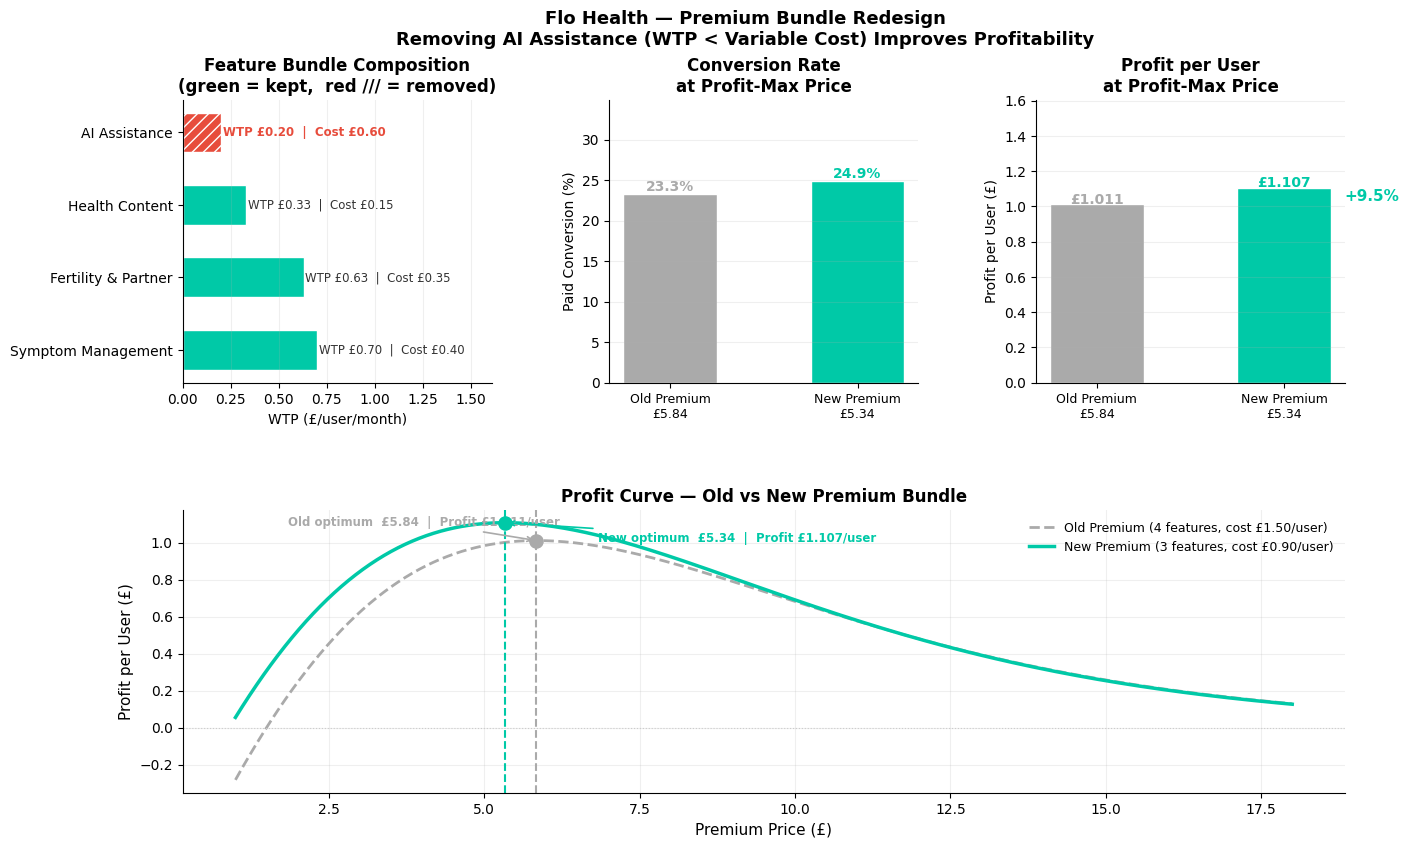

In [12]:
# ── Before vs After: Full Comparison ──────────────────────────────────────
PINK = '#e91e8c'
TEAL = '#00c9a7'
GRAY = '#aaaaaa'
RED  = '#e74c3c'

s_old_opt, _ = premium_strategy(opt_prof_var)
s_new_opt, _ = premium_strategy_new(opt_prof_new)
profit_old_opt = (opt_prof_var - cost_premium) * s_old_opt[1]
profit_new_opt = (opt_prof_new - cost_new)     * s_new_opt[1]

fig = plt.figure(figsize=(15, 9))
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── [0,0] Feature composition ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
wtp_all  = [wtp[f] for f in features]
cost_all = [feature_costs[f] for f in features]
colors_f = [TEAL if f in features_new else RED  for f in features]
hatches  = [''   if f in features_new else '///' for f in features]

bars = ax.barh([labels[f] for f in features], wtp_all,
               color=colors_f, edgecolor='white', height=0.55)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
for b, wv, cv, f in zip(bars, wtp_all, cost_all, features):
    col = RED if wv < cv else '#333'
    fw  = 'bold' if wv < cv else 'normal'
    ax.text(wv + 0.01, b.get_y() + b.get_height()/2,
            f'WTP £{wv:.2f}  |  Cost £{cv:.2f}',
            va='center', fontsize=8.5, color=col, fontweight=fw)

ax.set_xlabel('WTP (£/user/month)')
ax.set_title('Feature Bundle Composition\n(green = kept,  red /// = removed)',
             fontweight='bold')
ax.set_xlim(0, max(wtp_all) * 2.3)
ax.grid(axis='x', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── [0,1] Conversion rate at profit-max ────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
conv_vals = [s_old_opt[1]*100, s_new_opt[1]*100]

bars = ax.bar([0, 1], conv_vals, color=[GRAY, TEAL], width=0.5, edgecolor='white')
for i, v in enumerate(conv_vals):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=10,
            color=GRAY if i == 0 else TEAL, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels([f'Old Premium\n£{opt_prof_var}',
                    f'New Premium\n£{opt_prof_new}'], fontsize=9)
ax.set_ylabel('Paid Conversion (%)')
ax.set_title('Conversion Rate\nat Profit-Max Price', fontweight='bold')
ax.set_ylim(0, max(conv_vals) * 1.4)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── [0,2] Profit/user at profit-max ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
prof_vals = [profit_old_opt, profit_new_opt]

bars = ax.bar([0, 1], prof_vals, color=[GRAY, TEAL], width=0.5, edgecolor='white')
for i, v in enumerate(prof_vals):
    ax.text(i, v + 0.002, f'£{v:.3f}', ha='center', fontsize=10,
            color=GRAY if i == 0 else TEAL, fontweight='bold')

chg = (profit_new_opt - profit_old_opt) / profit_old_opt * 100
ax.annotate('', xy=(1, profit_new_opt - 0.003),
            xytext=(1, profit_old_opt + 0.003),
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=2.5))
ax.text(1.32, (profit_old_opt + profit_new_opt) / 2,
        f'+{chg:.1f}%', color=TEAL, fontsize=11, fontweight='bold', va='center')

ax.set_xticks([0, 1])
ax.set_xticklabels([f'Old Premium\n£{opt_prof_var}',
                    f'New Premium\n£{opt_prof_new}'], fontsize=9)
ax.set_ylabel('Profit per User (£)')
ax.set_title('Profit per User\nat Profit-Max Price', fontweight='bold')
ax.set_ylim(0, max(prof_vals) * 1.45)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── [1,:] Profit curves ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, :])
price_r      = np.linspace(1.0, 18, 300)
profit_old_c = [(p - cost_premium) * premium_strategy(p)[0][1]     for p in price_r]
profit_new_c = [(p - cost_new)     * premium_strategy_new(p)[0][1] for p in price_r]

ax.plot(price_r, profit_old_c, color=GRAY, lw=2, linestyle='--',
        label=f'Old Premium (4 features, cost £{cost_premium:.2f}/user)')
ax.plot(price_r, profit_new_c, color=TEAL, lw=2.5,
        label=f'New Premium (3 features, cost £{cost_new:.2f}/user)')
ax.axhline(0, color='#ccc', lw=0.8, linestyle=':')
ax.axvline(opt_prof_var, color=GRAY, lw=1.5, linestyle='--')
ax.axvline(opt_prof_new, color=TEAL, lw=1.5, linestyle='--')
ax.scatter([opt_prof_var], [profit_old_opt], color=GRAY, s=90, zorder=5)
ax.scatter([opt_prof_new], [profit_new_opt], color=TEAL, s=90, zorder=5)

ax.annotate(f'Old optimum  £{opt_prof_var}  |  Profit £{profit_old_opt:.3f}/user',
            xy=(opt_prof_var, profit_old_opt),
            xytext=(opt_prof_var - 4.0, profit_old_opt + 0.08),
            fontsize=8.5, color=GRAY, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.2))
ax.annotate(f'New optimum  £{opt_prof_new}  |  Profit £{profit_new_opt:.3f}/user',
            xy=(opt_prof_new, profit_new_opt),
            xytext=(opt_prof_new + 1.5, profit_new_opt - 0.10),
            fontsize=8.5, color=TEAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.2))

ax.set_xlabel('Premium Price (£)', fontsize=11)
ax.set_ylabel('Profit per User (£)', fontsize=11)
ax.set_title('Profit Curve — Old vs New Premium Bundle', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Flo Health — Premium Bundle Redesign\n'
    'Removing AI Assistance (WTP < Variable Cost) Improves Profitability',
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


# Traditional ML methods

# Benchmark: Traditional A/B Testing vs Conjoint + MNL

A traditional company without a structural model would rely on **empirical A/B price tests** to find the revenue-maximising price.  
We simulate this alternative approach using the MNL model as the data-generating process (ground truth), then compare to our conjoint + MNL framework.


In [13]:
# ── Traditional Approach: A/B Profit Testing ─────────────────────────────
# Known: current (price=9.99, rev/user=0.803, cost=1.50)
# The firm A/B tests prices and maximises (price − cost) × conversion.
# It treats the bundle as fixed — cost is always £1.50.

np.random.seed(42)

COST_BUNDLE = cost_premium   # £1.50 — the only cost info available to traditional firm
n_per_arm   = 1000

# Test a grid of prices (firm would try sensible range given current £9.99 baseline)
ab_prices = [2.99, 3.99, 4.99, 5.99, 6.99, 7.99, 9.99, 11.99]

# Ground truth: use MNL conversion (unobservable to firm, we just need a DGP)
true_convs   = [premium_strategy(p)[0][1] for p in ab_prices]
obs_counts   = [np.random.binomial(n_per_arm, c) for c in true_convs]
obs_convs    = [k / n_per_arm for k in obs_counts]
obs_profits  = [(p - COST_BUNDLE) * c for p, c in zip(ab_prices, obs_convs)]

# Firm picks price with highest observed profit/user
best_idx        = int(np.argmax(obs_profits))
ab_best_price   = ab_prices[best_idx]
ab_best_profit  = obs_profits[best_idx]
ab_best_conv    = obs_convs[best_idx]

print(f"A/B Profit Test  (N={n_per_arm} per arm, bundle cost fixed at £{COST_BUNDLE:.2f})")
print("─" * 65)
print(f"{'Price':>7}  {'Obs Conv':>10}  {'Obs Profit/user':>16}")
for i, (p, oc, pf) in enumerate(zip(ab_prices, obs_convs, obs_profits)):
    marker = '  ◄ WINNER' if i == best_idx else ''
    print(f"  £{p:>5}  {oc*100:>9.1f}%  £{pf:>14.3f}{marker}")

print()
print(f"  Baseline  (£9.99):  profit/user = £{(9.99 - COST_BUNDLE) * shares_cur[1]:.3f}")
print(f"  A/B optimum (£{ab_best_price}):  profit/user = £{ab_best_profit:.3f}")
print(f"  True MNL profit-max (£{opt_prof_var}, 4 feat):  profit/user = £{(opt_prof_var - COST_BUNDLE) * shares_pv[1]:.3f}")
print()
print("  What A/B CANNOT discover:")
print("   – Which of the 4 features contributes most/least WTP")
print("   – That AI Assistance costs £0.60 but users value it at only £0.20")
print("   – That removing AI reduces cost to £0.90 and unlocks higher profit")


A/B Profit Test  (N=1000 per arm, bundle cost fixed at £1.50)
─────────────────────────────────────────────────────────────────
  Price    Obs Conv   Obs Profit/user
  £ 2.99       40.3%  £         0.600
  £ 3.99       34.8%  £         0.867
  £ 4.99       26.0%  £         0.907
  £ 5.99       23.1%  £         1.037  ◄ WINNER
  £ 6.99       15.6%  £         0.856
  £ 7.99       14.8%  £         0.961
  £ 9.99        8.2%  £         0.696
  £11.99        4.7%  £         0.493

  Baseline  (£9.99):  profit/user = £0.683
  A/B optimum (£5.99):  profit/user = £1.037
  True MNL profit-max (£5.84, 4 feat):  profit/user = £1.011

  What A/B CANNOT discover:
   – Which of the 4 features contributes most/least WTP
   – That AI Assistance costs £0.60 but users value it at only £0.20
   – That removing AI reduces cost to £0.90 and unlocks higher profit


In [14]:
# ── Final Comparison: Baseline / A/B / Conjoint+MNL ──────────────────────

PINK = '#e91e8c'
TEAL = '#00c9a7'
GRAY = '#aaaaaa'
BLUE = '#3b82f6'

# Three scenarios
scenarios   = ['Baseline\n£9.99', f'A/B Optimised\n£{ab_best_price}', f'Conjoint+MNL\n£{opt_prof_new}\n(AI removed)']
profits     = [profit_baseline, profit_ab, profit_mnl_3f]
convs       = [shares_cur[1]*100, ab_best_conv*100, shares_pv_new[1]*100]
colors      = [GRAY, BLUE, TEAL]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ─ Left: Profit per user ────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(scenarios, profits, color=colors, width=0.45, edgecolor='white')
for b, v in zip(bars, profits):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005,
            f'£{v:.3f}', ha='center', fontsize=11, fontweight='bold')

for i in range(1, 3):
    uplift = (profits[i] - profits[0]) / profits[0] * 100
    ax.text(i, profits[i] + 0.05, f'+{uplift:.0f}% vs baseline',
            ha='center', fontsize=8.5, color=colors[i])

ax.set_ylabel('Profit per User (£/month)', fontsize=11)
ax.set_title('Profit per User', fontweight='bold')
ax.set_ylim(0, max(profits) * 1.45)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ─ Right: Conversion rate ────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(scenarios, convs, color=colors, width=0.45, edgecolor='white')
for b, v in zip(bars, convs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3,
            f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Paid Conversion Rate (%)', fontsize=11)
ax.set_title('Conversion Rate', fontweight='bold')
ax.set_ylim(0, max(convs) * 1.35)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Flo Health — Baseline vs A/B Testing vs Conjoint + MNL',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.show()

print(f"{'Scenario':<30} {'Price':>7}  {'Conv':>8}  {'Profit/user':>13}")
print("─" * 65)
print(f"{'Baseline':<30} {'£9.99':>7}  {shares_cur[1]*100:>7.1f}%  £{profit_baseline:>11.3f}")
print(f"{'A/B Optimised':<30} £{ab_best_price:>5}  {ab_best_conv*100:>7.1f}%  £{profit_ab:>11.3f}")
print(f"{'Conjoint+MNL (AI removed)':<30} £{opt_prof_new:>5}  {shares_pv_new[1]*100:>7.1f}%  £{profit_mnl_3f:>11.3f}")


NameError: name 'profit_baseline' is not defined

In [ ]:
# ── WTP vs Cost  +  Profit Curves (4-feat vs 3-feat) ─────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PINK = '#e91e8c'
TEAL = '#00c9a7'
BLUE = '#3b82f6'
GRAY = '#888888'

# ── Feature-level data (from conjoint betas) ──────────────────────────────
# Adjust variable names to match your notebook
features      = ['Ad-Free\nExperience', 'Personalised\nInsights', 'Expert\nConsultations', 'AI Health\nAssistance']
wtp_vals      = [wtp_ad_free, wtp_insights, wtp_expert, wtp_ai]     # your WTP variables
cost_vals     = [cost_ad_free, cost_insights, cost_expert, cost_ai]  # your cost variables

# ── Profit curves ─────────────────────────────────────────────────────────
price_range = np.linspace(0.5, 18, 400)

profit_4f = [(p - cost_premium) * premium_strategy(p)[0][1]   for p in price_range]
profit_3f = [(p - cost_new)     * premium_strategy_new(p)[0][1] for p in price_range]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─ Left: WTP vs Variable Cost per feature ────────────────────────────────
ax = axes[0]
x      = np.arange(len(features))
width  = 0.35

bars_wtp  = ax.bar(x - width/2, wtp_vals,  width, label='WTP (conjoint)',   color=PINK,  edgecolor='white')
bars_cost = ax.bar(x + width/2, cost_vals, width, label='Variable Cost',    color=TEAL,  edgecolor='white')

# Value labels
for b in bars_wtp:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'£{b.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=PINK)
for b in bars_cost:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'£{b.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=TEAL)

# Highlight AI bar pair — where WTP < Cost
ax.axhspan(0, max(cost_vals) * 1.05, xmin=(x[-1] - width - 0.05) / (len(features) - 0.3),
           xmax=(x[-1] + width + 0.05) / (len(features) - 0.3),
           alpha=0.07, color='red', zorder=0)
ax.text(x[-1], max(wtp_vals[-1], cost_vals[-1]) + 0.08,
        'WTP < Cost', ha='center', fontsize=8.5, color='red', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(features, fontsize=9.5)
ax.set_ylabel('£ per user / month', fontsize=11)
ax.set_title('WTP vs Variable Cost per Feature', fontweight='bold')
ax.legend(fontsize=9.5, frameon=False)
ax.set_ylim(0, max(max(wtp_vals), max(cost_vals)) * 1.35)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ─ Right: Profit curves ──────────────────────────────────────────────────
ax = axes[1]

ax.plot(price_range, profit_4f, color=BLUE, lw=2.5,
        label='4 features  (cost £1.50)')
ax.plot(price_range, profit_3f, color=TEAL, lw=2.5, linestyle='--',
        label='3 features, AI removed  (cost £0.90)')

# Current price dashed line
ax.axvline(9.99, color=GRAY, lw=1.8, linestyle=':', label='Current price £9.99')
ax.text(9.99 + 0.2, max(max(profit_4f), max(profit_3f)) * 0.92,
        'Current\n£9.99', fontsize=8.5, color=GRAY, va='top')

# Optima dots
idx4 = int(np.argmax(profit_4f))
idx3 = int(np.argmax(profit_3f))
ax.scatter(price_range[idx4], profit_4f[idx4], color=BLUE, s=70, zorder=5)
ax.scatter(price_range[idx3], profit_3f[idx3], color=TEAL, s=70, zorder=5)
ax.annotate(f'£{price_range[idx4]:.2f}\n£{profit_4f[idx4]:.3f}/user',
            xy=(price_range[idx4], profit_4f[idx4]),
            xytext=(price_range[idx4] - 3.5, profit_4f[idx4] - 0.05),
            fontsize=8, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2))
ax.annotate(f'£{price_range[idx3]:.2f}\n£{profit_3f[idx3]:.3f}/user',
            xy=(price_range[idx3], profit_3f[idx3]),
            xytext=(price_range[idx3] + 1, profit_3f[idx3] + 0.05),
            fontsize=8, color=TEAL,
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.2))

ax.axhline(0, color='black', lw=0.8, alpha=0.4)
ax.set_xlabel('Price (£)', fontsize=11)
ax.set_ylabel('Profit per User (£/month)', fontsize=11)
ax.set_title('Profit Curve: 4 Features vs 3 Features', fontweight='bold')
ax.legend(fontsize=9.5, frameon=False)
ax.grid(alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Feature Value Analysis & Profit Optimisation — Flo Health Premium',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.show()


NameError: name 'wtp_ad_free' is not defined